Question: Is it possible to predict whether a consumer prefers online shopping vs in-store shopping, and which factors matter most?

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

In [73]:
df = pd.read_csv('/Users/owencorley/Downloads/Project 2/Consumer_Shopping_Trends_2026 (6).csv')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df['shopping_preference'].value_counts()}")

Dataset shape: (11789, 25)

Target distribution:
shopping_preference
Store     10244
Online     1176
Hybrid      369
Name: count, dtype: int64


In [ ]:
df = dropna()

In [75]:
df_encoded = df.copy()

In [76]:
df_encoded['gender'] = LabelEncoder().fit_transform(df_encoded['gender'])
df_encoded['city_tier'] = LabelEncoder().fit_transform(df_encoded['city_tier'])

In [77]:
df_encoded['is_online'] = (df['shopping_preference'] == 'Online').astype(int)
print(f"\nBinary target distribution:\n{df_encoded['is_online'].value_counts()}")
print(f"Online shoppers: {df_encoded['is_online'].mean()*100:.1f}% of total")


Binary target distribution:
is_online
0    10613
1     1176
Name: count, dtype: int64
Online shoppers: 10.0% of total


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

# Class weights to handle 10% minority class
weights = class_weight.compute_sample_weight('balanced', y_train)


Train size: 9431 | Test size: 2358


In [79]:
models = {
    # Simple interpretable linear baseline; class_weight handles imbalance
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    # Non-linear; max_depth limits overfitting
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=8),
    # Ensemble of trees; averages out overfitting
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    # Sequential boosting; uses sample_weight since no class_weight param
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

In [80]:
results = {}
for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train, y_train, sample_weight=weights)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # 5-fold stratified cross-validation for robustness check
    cv = cross_val_score(model, X, y, cv=StratifiedKFold(5), scoring='roc_auc')

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': model.score(X_test, y_test),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'cv_mean': cv.mean(), 'cv_std': cv.std(),
    }


In [81]:
print("\n" + "="*65)
print("MODEL EVALUATION RESULTS")
print("="*65)
for name, r in results.items():
    print(f"\n── {name} ──")
    print(f"  Test ROC-AUC:    {r['roc_auc']:.3f}")
    print(f"  5-Fold CV AUC:   {r['cv_mean']:.3f} ± {r['cv_std']:.3f}")
    print(f"  Test Accuracy:   {r['accuracy']:.3f}")
    print(classification_report(y_test, r['y_pred'], target_names=['Not Online', 'Online']))

best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"\n{'='*65}")
print(f"Best model by ROC-AUC: {best_name} ({results[best_name]['roc_auc']:.3f})")
print("="*65)



MODEL EVALUATION RESULTS

── Logistic Regression ──
  Test ROC-AUC:    0.689
  5-Fold CV AUC:   0.697 ± 0.018
  Test Accuracy:   0.618
              precision    recall  f1-score   support

  Not Online       0.94      0.62      0.74      2123
      Online       0.15      0.63      0.25       235

    accuracy                           0.62      2358
   macro avg       0.55      0.62      0.50      2358
weighted avg       0.86      0.62      0.69      2358


── Decision Tree ──
  Test ROC-AUC:    0.589
  5-Fold CV AUC:   0.616 ± 0.012
  Test Accuracy:   0.576
              precision    recall  f1-score   support

  Not Online       0.93      0.57      0.71      2123
      Online       0.13      0.60      0.22       235

    accuracy                           0.58      2358
   macro avg       0.53      0.58      0.46      2358
weighted avg       0.85      0.58      0.66      2358


── Random Forest ──
  Test ROC-AUC:    0.653
  5-Fold CV AUC:   0.656 ± 0.011
  Test Accuracy:   0.900
  

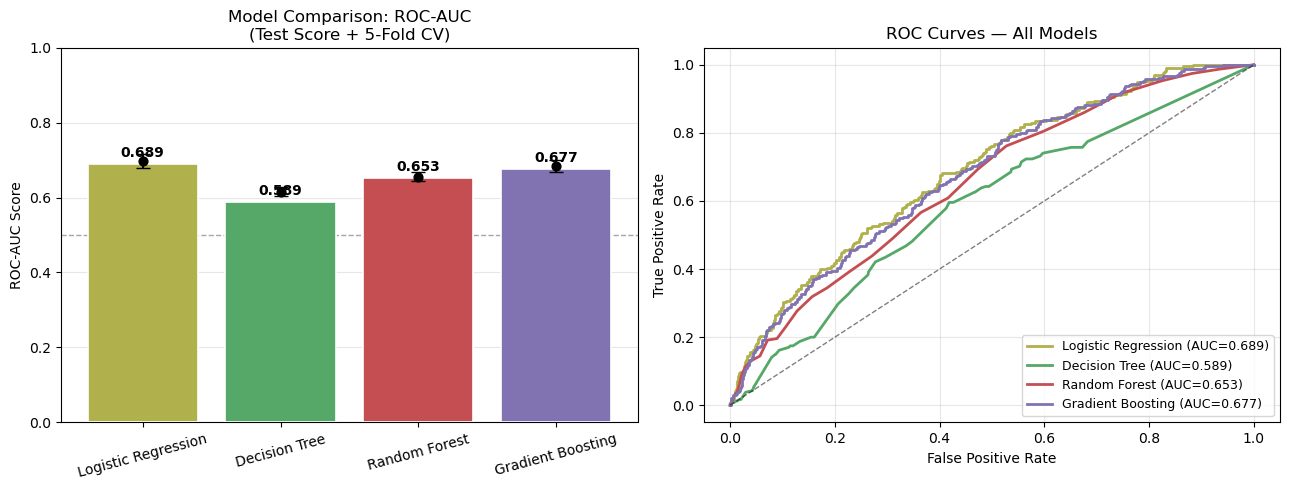

In [82]:
COLORS = {
    'Logistic Regression': "#B0B04C",
    'Decision Tree':       '#55A868',
    'Random Forest':       '#C44E52',
    'Gradient Boosting':   '#8172B2'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names = list(results.keys())
aucs = [results[n]['roc_auc'] for n in names]
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds = [results[n]['cv_std'] for n in names]
colors = [COLORS[n] for n in names]

bars = axes[0].bar(names, aucs, color=colors, edgecolor='white', linewidth=1.2, zorder=3)
axes[0].errorbar(names, cv_means, yerr=cv_stds, fmt='none', color='black',
                 capsize=5, linewidth=1.5, zorder=4)
axes[0].scatter(names, cv_means, color='black', zorder=5, s=40)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('ROC-AUC Score')
axes[0].set_title('Model Comparison: ROC-AUC\n(Test Score + 5-Fold CV)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for name, color in COLORS.items():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

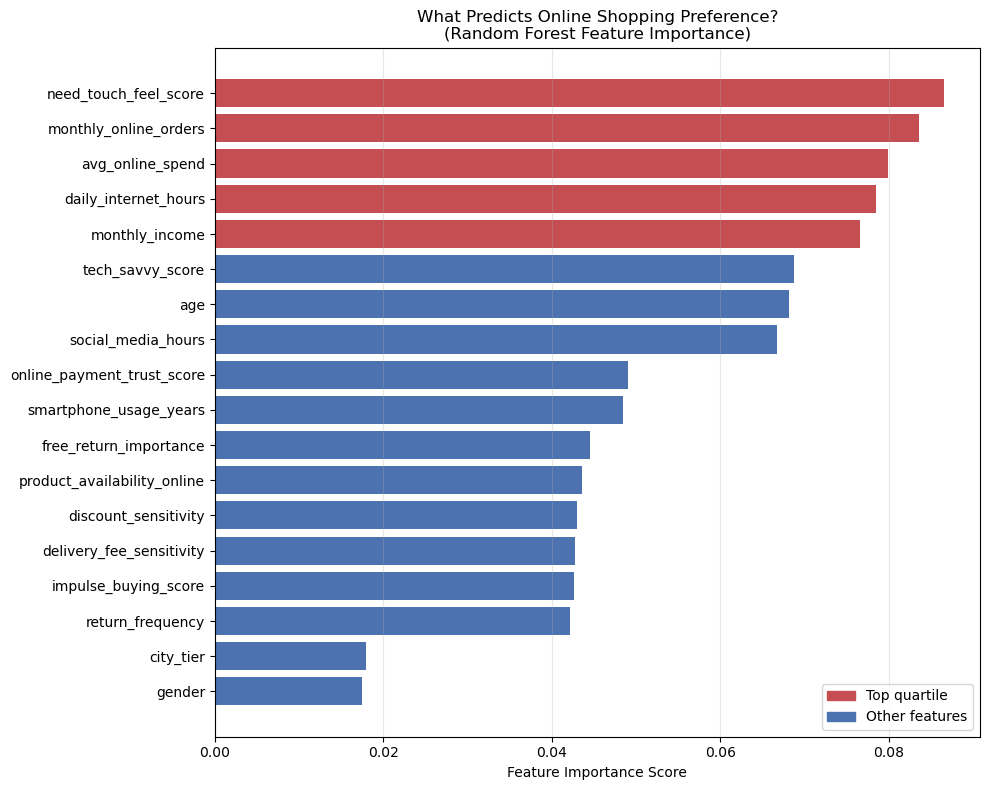

In [83]:
import matplotlib.patches as mpatches
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
bar_colors = ['#C44E52' if importances[f] >= importances.quantile(0.75) else '#4C72B0'
              for f in importances.index]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importances.index, importances.values, color=bar_colors)
ax.set_xlabel('Feature Importance Score')
ax.set_title('What Predicts Online Shopping Preference?\n(Random Forest Feature Importance)')
ax.grid(axis='x', alpha=0.3)
top_patch = mpatches.Patch(color='#C44E52', label='Top quartile')
rest_patch = mpatches.Patch(color='#4C72B0', label='Other features')
ax.legend(handles=[top_patch, rest_patch])
plt.tight_layout()
plt.savefig('fig2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

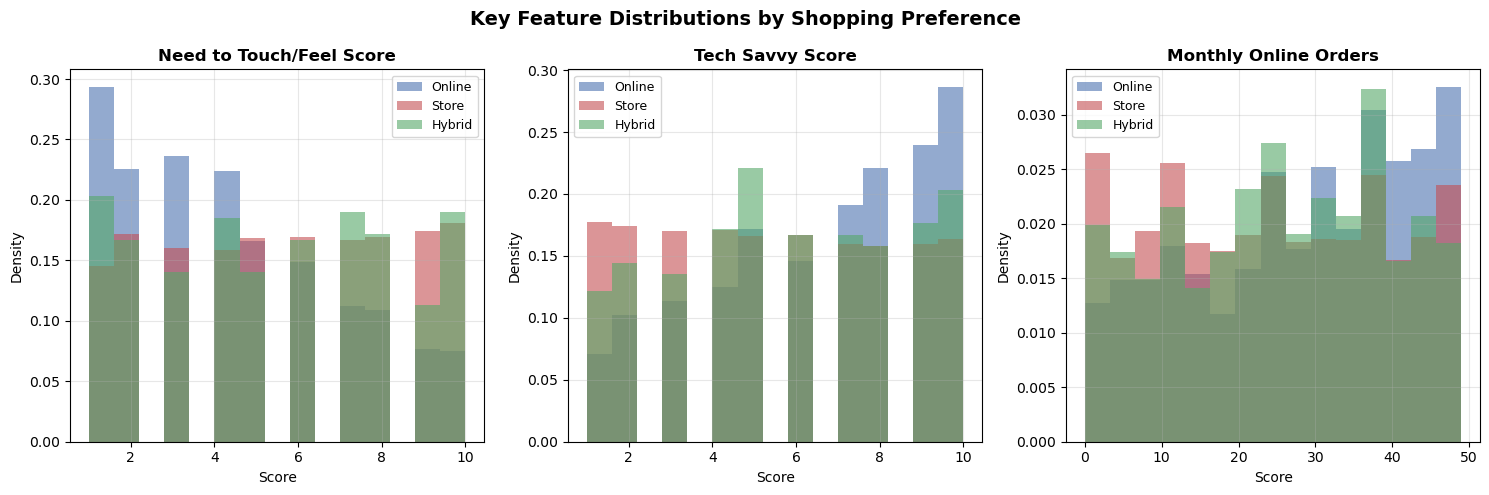

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
palette = {'Online': '#4C72B0', 'Store': '#C44E52', 'Hybrid': '#55A868'}
plot_features = [
    ('need_touch_feel_score', 'Need to Touch/Feel Score'),
    ('tech_savvy_score', 'Tech Savvy Score'),
    ('monthly_online_orders', 'Monthly Online Orders'),
]
for ax, (feat, label) in zip(axes, plot_features):
    for pref, color in palette.items():
        ax.hist(df[df['shopping_preference'] == pref][feat],
                bins=15, alpha=0.6, color=color, label=pref, density=True)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.suptitle('Key Feature Distributions by Shopping Preference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

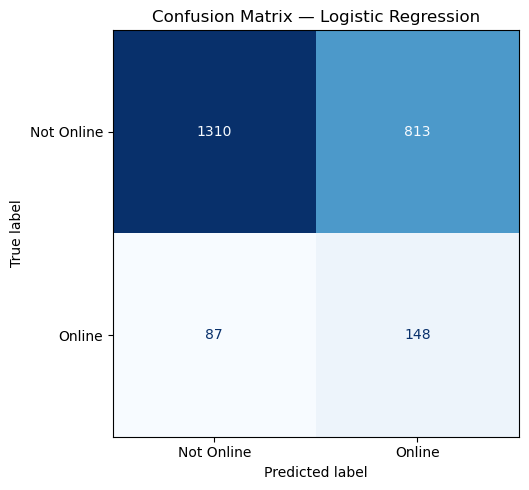

In [85]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Online','Online']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.savefig('fig4_confusion.png', dpi=150, bbox_inches='tight')
plt.show()